# Vector Fields - Reactive Algorithms Pt 2.
## Free Vortex - Finding the Centre and circumnavigation - 3 approaches

### 1. But First, a little visualization

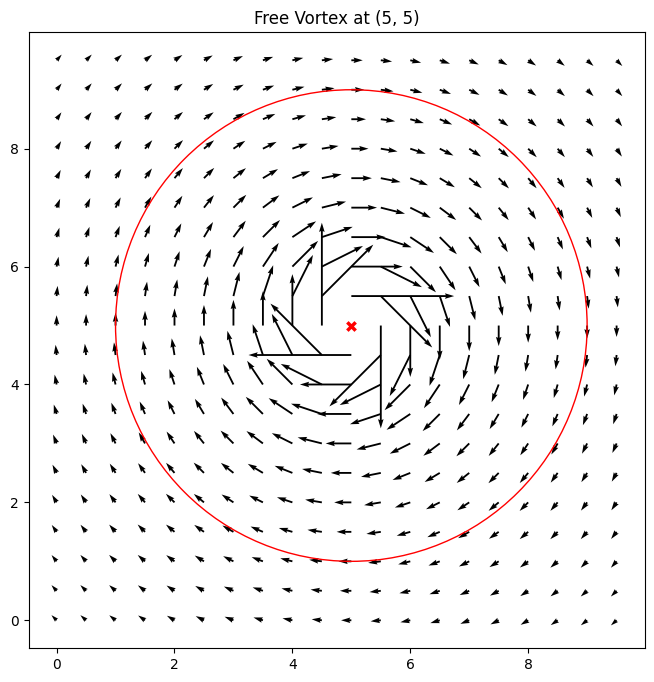

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")

# Add source point
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)
circle = plt.Circle((5,5), 4, color='red', fill=False)
plt.gca().add_patch(circle)
plt.gca().set_aspect('equal')
plt.show()


## Direction Follower Method - Find Centre of Vortex

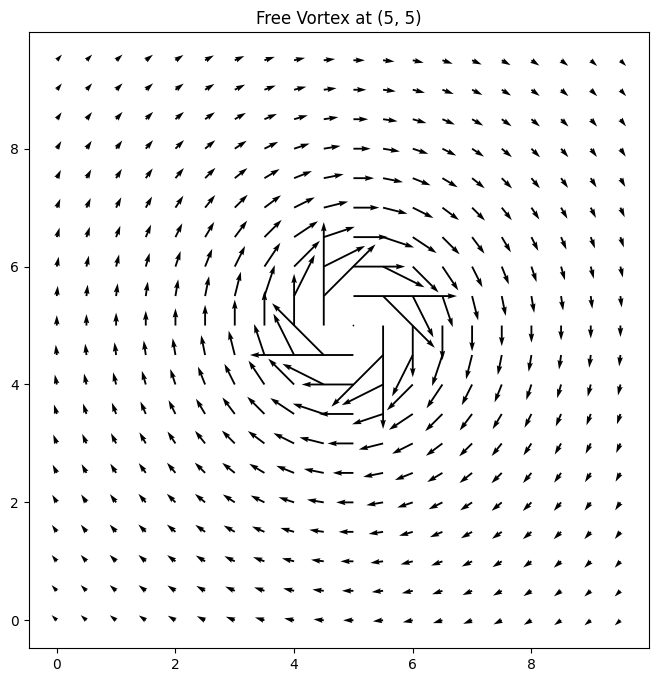

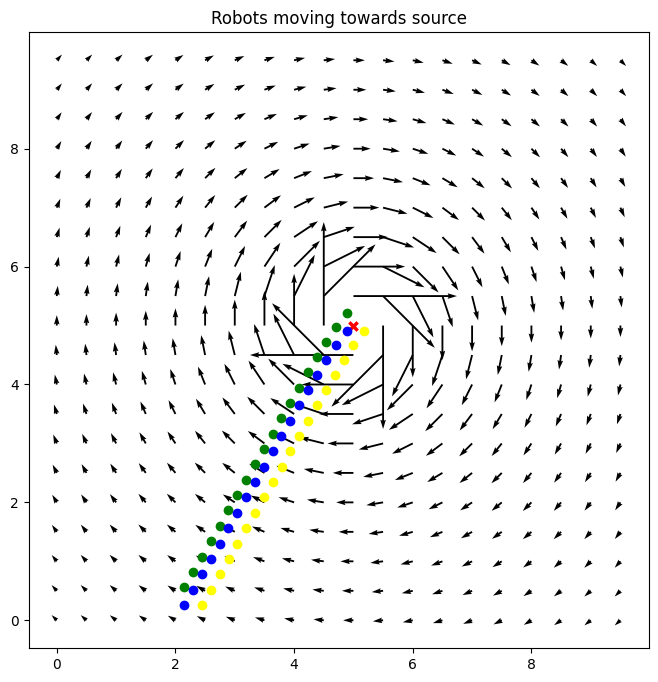

It took this many steps:  19


In [66]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()


# 2. Initializing the robot positions

x1 = 2
y1 = 0
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.3
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# 3. Algorithm to move towards source

for _ in range (1,30):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

    # Calculate the velocity at distance r1 for any theta
    v_theta1 = 1 / r1

    # Projectcting into x and y
    u1 = v_theta1 * v_dist1 / r1
    v1 = -v_theta1 * u_dist1 / r1

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = -v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = -v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    
    # Computing Direction of Source
    # Recasting Position with Magnitude
#     poss1 = np.array([*pos1,magnitude1])
#     poss2 = np.array([*pos2,magnitude2])
#     poss3 = np.array([*pos3,magnitude3])

#     # Calculate vectors R12 and R13
#     R12 = poss2 - poss1
#     R13 = poss3 - poss1

#     # Calculate the cross product of R12 and R13 - the normal vector
#     Nx , Ny, _ = np.cross(-R12, R13)
#     angle = np.arctan2(Ny, Nx)
    angle = (angle1 + angle2 + angle3) / 3 + np.pi/2
   
    # Break Condition
    if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
        pass
    else:
        break

    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving towards source")
plt.show()
print('It took this many steps: ', steps)

In [55]:
magnitude1, magnitude2, magnitude3

(0.18758342864356503, 0.1929438529067989, 0.1969996998213321)

In [57]:
angle, bgrad

(1.036226269718901, 2.088315587689081)

## Direction Follower Method - Circumnavigate the Vortex

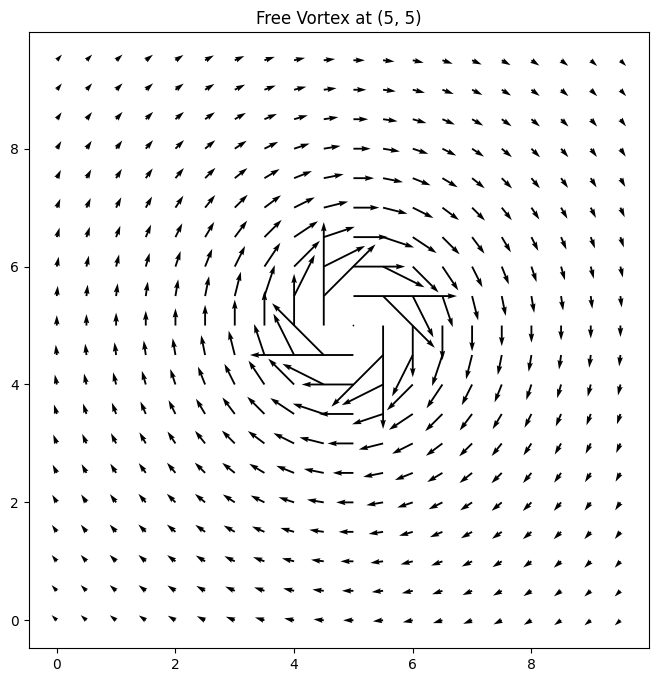

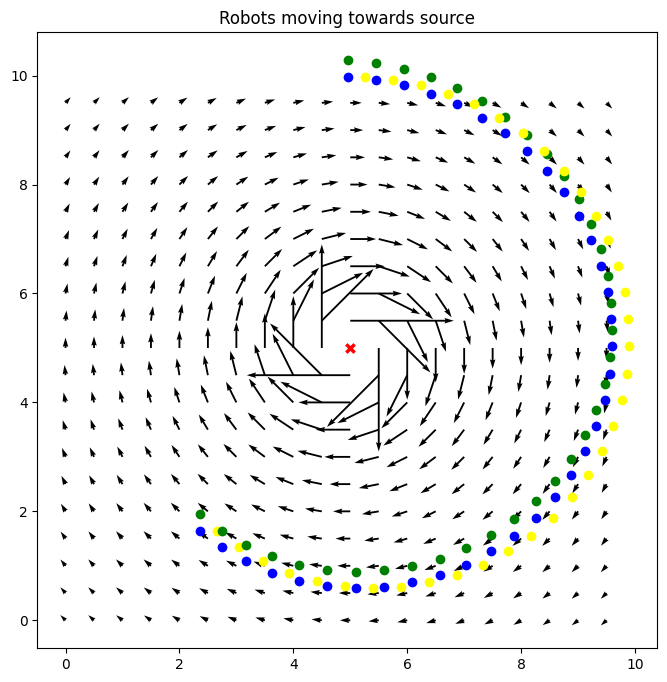

It took this many steps:  36


In [58]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()


# 2. Initializing the robot positions

x1 = 2
y1 = 2
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.5
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# 3. Algorithm to move towards source

for _ in range (1,100):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

    # Calculate the velocity at distance r1 for any theta
    v_theta1 = 1 / r1

    # Projectcting into x and y
    u1 = v_theta1 * v_dist1 / r1
    v1 = -v_theta1 * u_dist1 / r1

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = -v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = -v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    
    # Computing Direction of Source
    angle = (angle1 + angle2 + angle3) / 3
   
    # Break Condition
    if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
        pass
    else:
        break

    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving towards source")
plt.show()
print('It took this many steps: ', steps)

## Magnitude Follower - Finding Source

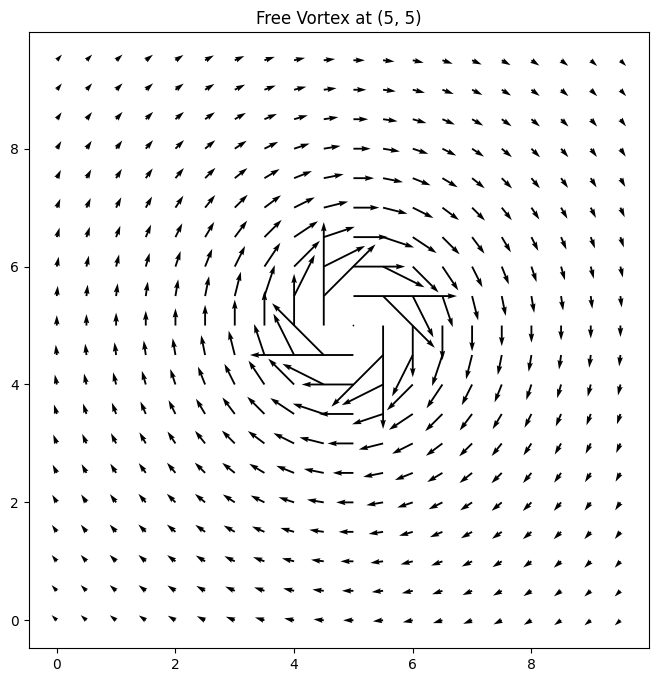

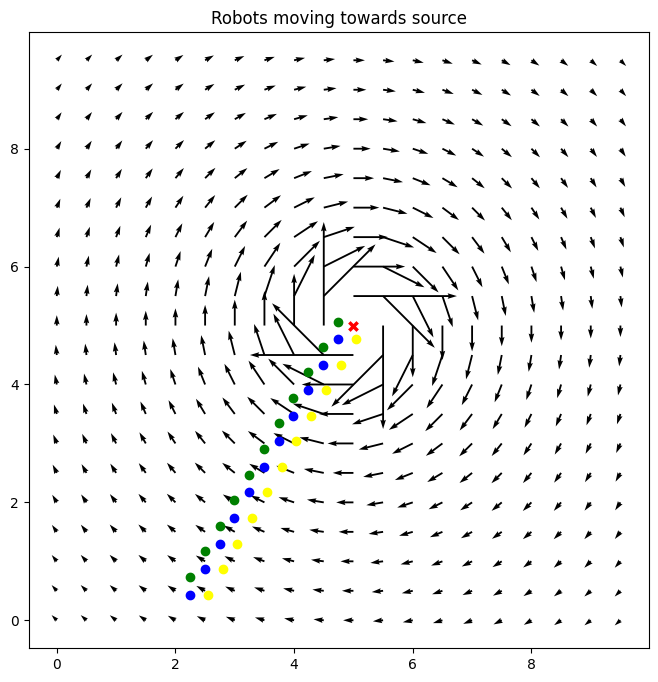

It took this many steps:  11


In [24]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()


# 2. Initializing the robot positions

x1 = 2
y1 = 0
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.5
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# 3. Algorithm to move towards source

for _ in range (1,40):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

    # Calculate the velocity at distance r1 for any theta
    v_theta1 = 1 / r1

    # Projectcting into x and y
    u1 = v_theta1 * v_dist1 / r1
    v1 = -v_theta1 * u_dist1 / r1

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = -v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = -v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    
    #Determing Direction
    slope_x = (magnitude2 - magnitude1) / (x2-x1) 
    slope_y = (magnitude3 - magnitude1) / (y3-y1)
    source_direction = np.arctan2(slope_y,slope_x)
   
    # Break Condition
    if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
        pass
    else:
        break
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(source_direction)
    pos1[1] += step_size*np.sin(source_direction)
    pos2[0] += step_size*np.cos(source_direction)
    pos2[1] += step_size*np.sin(source_direction)
    pos3[0] += step_size*np.cos(source_direction)
    pos3[1] += step_size*np.sin(source_direction)
    
    
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving towards source")
plt.show()
print('It took this many steps: ', steps)

In [5]:
print(slope_x)
print(slope_y)
print(source_direction)

-6.416238216289117e-06
7.356399908476911
1.570797198993023


## Magnitude Follower - Circum-navigate the Vortex

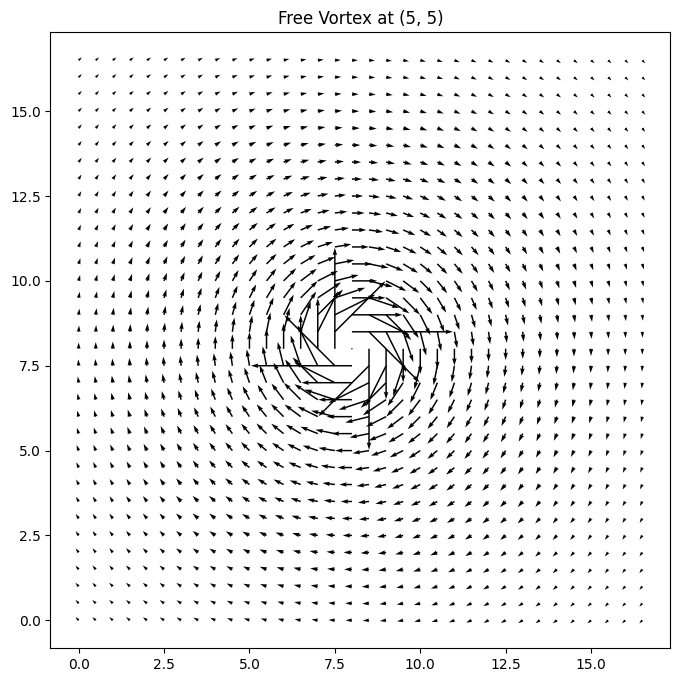

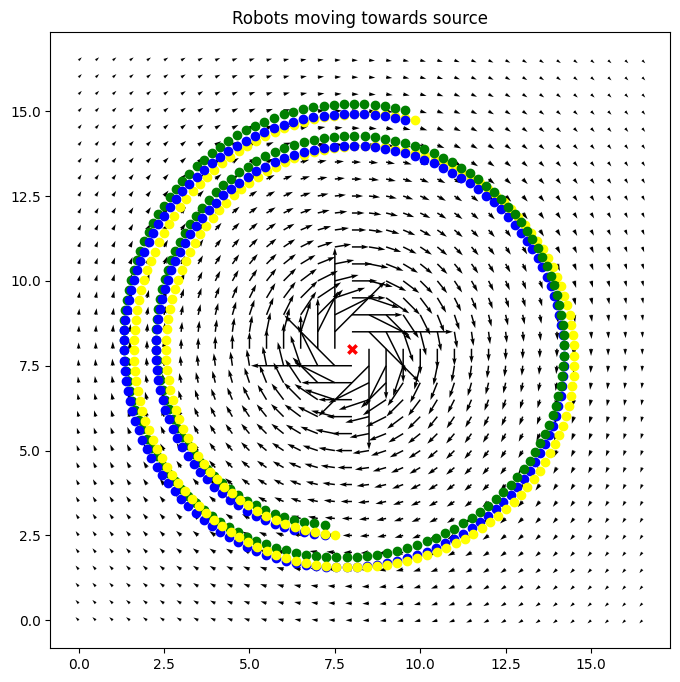

It took this many steps:  199


In [22]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 17, 0.5)
y = np.arange(0, 17, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 8
y_source = 8

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()


# 2. Initializing the robot positions

x1 = 7.5
y1 = 2.5
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.3
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

# 3. Algorithm to move towards source

for _ in range (1,200):
    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

    # Calculate the velocity at distance r1 for any theta
    v_theta1 = 1 / r1

    # Projectcting into x and y
    u1 = v_theta1 * v_dist1 / r1
    v1 = -v_theta1 * u_dist1 / r1

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = -v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = -v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    
    #Determing Direction
    slope_x = (magnitude2 - magnitude1) / (x2-x1) 
    slope_y = (magnitude3 - magnitude1) / (y3-y1)
    source_direction = np.arctan2(slope_y,slope_x) + np.pi/2
   

    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(source_direction)
    pos1[1] += step_size*np.sin(source_direction)
    pos2[0] += step_size*np.cos(source_direction)
    pos2[1] += step_size*np.sin(source_direction)
    pos3[0] += step_size*np.cos(source_direction)
    pos3[1] += step_size*np.sin(source_direction)
    
    
    steps += 1
    
  
    # Plot each robot
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


        
        
# 4. Visualize the output
plt.title("Robots moving towards source")
plt.show()
print('It took this many steps: ', steps)

## Source Finder Algorithm - New

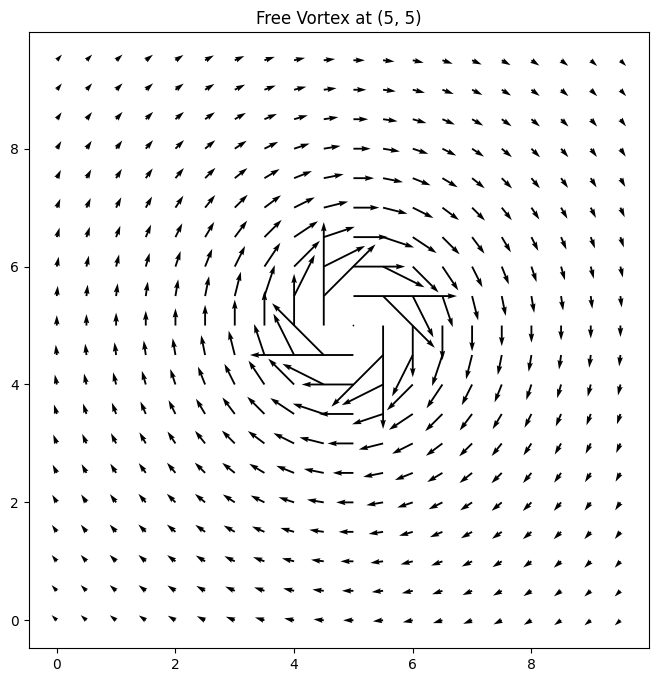

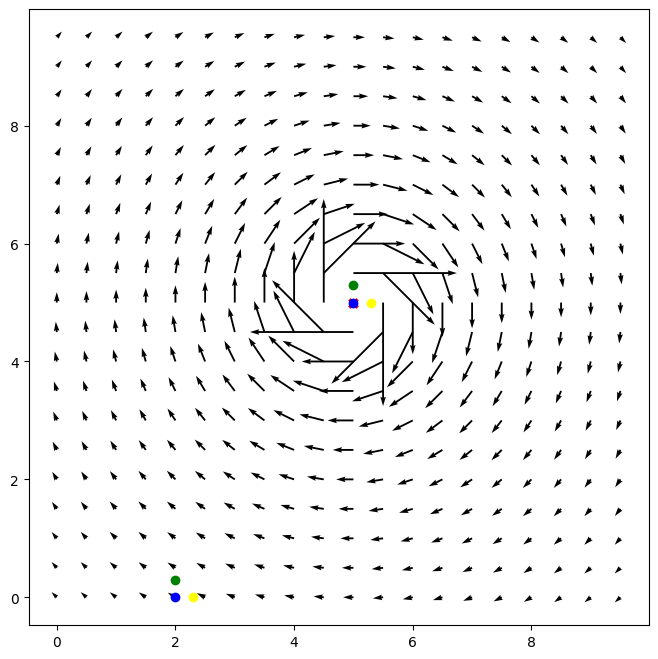

Estimated source position:  [5.0, 5.0]


In [38]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()

# Step 2. Defining Fxns

def find_source(pos1, angle1, pos2, angle2, pos3, angle3):
    # Set up symbols
    x, y = symbols('x y')

    # Calculate slopes of perpendicular lines
    m1 = -1 / np.tan(angle1)
    m2 = -1 / np.tan(angle2)
    m3 = -1 / np.tan(angle3)

    # Calculate y-intercepts of perpendicular lines
    b1 = pos1[1] - m1 * pos1[0]
    b2 = pos2[1] - m2 * pos2[0]
    b3 = pos3[1] - m3 * pos3[0]

    # Form equations which are perpendicular to the angles given
    eq1 = Eq(y, m1 * x + b1)
    eq2 = Eq(y, m2 * x + b2)
    eq3 = Eq(y, m3 * x + b3)

    # Find intersection of the lines
    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))

    # Average of intersection points
    avg_x = float((solution12[x] + solution23[x] + solution13[x]) / 3)
    avg_y = float((solution12[y] + solution23[y] + solution13[y]) / 3)

    source_location = [avg_x, avg_y]

    return source_location




# Step 3. Initializing the robot positions

x1 = 2
y1 = 0
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.5
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)


# Plot each robot at the start
plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


# Step 4. Algorithm to Determine where the source is


# Vector Magnitude and Direction at Robot 1
u_dist1 = pos1[0] - x_source
v_dist1 = pos1[1] - y_source

r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
r1 = 1e-6 if r1 == 0 else r1

# Calculate the velocity at distance r1 for any theta
v_theta1 = 1 / r1

# Projectcting into x and y
u1 = v_theta1 * v_dist1 / r1
v1 = -v_theta1 * u_dist1 / r1

magnitude1 = (u1**2 + v1**2)**0.5
angle1 = np.arctan2(-v1, -u1)


# Vector Magnitude and Direction at Robot 2
u_dist2 = pos2[0] - x_source
v_dist2 = pos2[1] - y_source

r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
r2 = 1e-6 if r2 == 0 else r2

# Calculate the velocity at distance r1 for any theta
v_theta2 = 1 / r2

# Projectcting into x and y
u2 = v_theta2 * v_dist2 / r2
v2 = -v_theta2 * u_dist2 / r2

magnitude2 = (u2**2 + v2**2)**0.5
angle2 = np.arctan2(-v2, -u2)

# Vector Magnitude and Direction at Robot 3
u_dist3 = pos3[0] - x_source
v_dist3 = pos3[1] - y_source

r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
r3 = 1e-6 if r3 == 0 else r3

# Calculate the velocity at distance r1 for any theta
v_theta3 = 1 / r3

# Projectcting into x and y
u3 = v_theta3 * v_dist3 / r3
v3 = -v_theta3 * u_dist3 / r3

magnitude3 = (u3**2 + v3**2)**0.5
angle3 = np.arctan2(-v3, -u3)

angle = -angle1+ angle2+angle3/3

  

# Determining Where the Source is
source_location = find_source(pos1, angle1, pos2, angle2, pos3, angle3)

# Updating the Robot Position

pos1[0] = source_location[0]
pos1[1] = source_location[1]
pos2[0] = pos1[0] + 0.3
pos2[1] = pos1[0]
pos3[0] = pos1[0]
pos3[1] = pos1[0] + 0.3

#Plotting the Final Location of the robots

plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
plt.show()
    
    
print('Estimated source position: ', source_location)


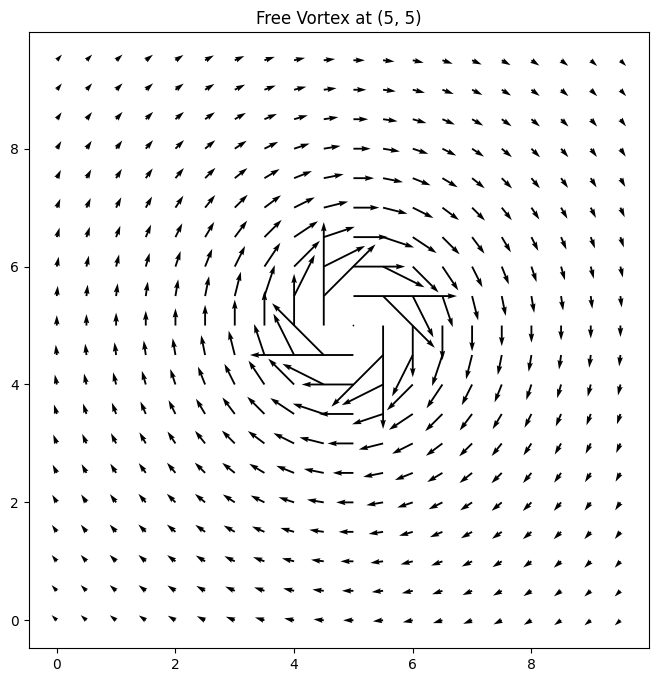

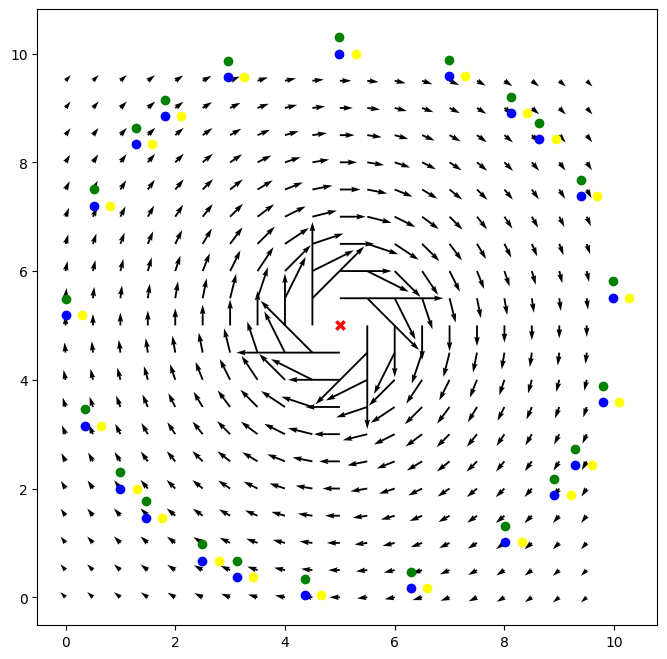

Estimated source position:  [5.000000000000056, 4.999999999999966]


In [67]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve

# 1. Creating the Environment For Visualization

# Create Meshgrid
x = np.arange(0, 10, 0.5)
y = np.arange(0, 10, 0.5)
X, Y = np.meshgrid(x, y)

# Source Location
x_source = 5
y_source = 5

# Centring over source
x_centre = X - x_source
y_centre = Y - y_source

# Radial Distance from Centre
r = np.sqrt(x_centre**2 + y_centre**2)

# Avoid division by zero at the center
r[r==0] = 1e-6

# Calculating a Vortex

# Calculate the angular component of the velocity
v_theta = 1 / r 

# Convert to cartesian coordinates
u = v_theta * y_centre / r
v = -v_theta * x_centre / r

# Plot the vortex
plt.figure(figsize=(8, 8))
plt.quiver(X, Y, u, v)
plt.title("Free Vortex at (5, 5)")
plt.show()

# Step 2. Defining Fxns

''' This function doesnt care about the magnitude of each vector. 
    To include this information, we can do a wegithes sum 
    when calculating avg_x and avg_y '''
def find_source(pos1, angle1, pos2, angle2, pos3, angle3):
    # Set up symbols
    x, y = symbols('x y')

    # Calculate slopes of perpendicular lines
    m1 = -1 / np.tan(angle1)
    m2 = -1 / np.tan(angle2)
    m3 = -1 / np.tan(angle3)

    # Calculate y-intercepts of perpendicular lines
    b1 = pos1[1] - m1 * pos1[0]
    b2 = pos2[1] - m2 * pos2[0]
    b3 = pos3[1] - m3 * pos3[0]

    # Form equations which are perpendicular to the angles given
    eq1 = Eq(y, m1 * x + b1)
    eq2 = Eq(y, m2 * x + b2)
    eq3 = Eq(y, m3 * x + b3)

    # Find intersection of the lines
    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))

    # Average of intersection points
    avg_x = float((solution12[x] + solution23[x] + solution13[x]) / 3)
    avg_y = float((solution12[y] + solution23[y] + solution13[y]) / 3)

    source_location = [avg_x, avg_y]

    return source_location




# Step 3. Initializing the robot positions

x1 = 1
y1 = 2
x2 = x1 + 0.3
y2 = y1
x3 = x1
y3 = y1+ 0.3
pos1 = [x1,y1]
pos2 = [x2,y2]
pos3 = [x3,y3]
step_size = 0.5
steps =0

plt.figure(figsize=(8,8))
plt.quiver(X,Y,u,v)
plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)


# Plot each robot at the start
plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')


# Step 4. Algorithm to Determine where the source is

for _ in range (1,22):

    # Vector Magnitude and Direction at Robot 1
    u_dist1 = pos1[0] - x_source
    v_dist1 = pos1[1] - y_source

    r1 = np.sqrt(u_dist1**2 + v_dist1**2) # Radial distance
    r1 = 1e-6 if r1 == 0 else r1

    # Calculate the velocity at distance r1 for any theta
    v_theta1 = 1 / r1

    # Projectcting into x and y
    u1 = v_theta1 * v_dist1 / r1
    v1 = -v_theta1 * u_dist1 / r1

    magnitude1 = (u1**2 + v1**2)**0.5
    angle1 = np.arctan2(-v1, -u1)


    # Vector Magnitude and Direction at Robot 2
    u_dist2 = pos2[0] - x_source
    v_dist2 = pos2[1] - y_source

    r2 = np.sqrt(u_dist2**2 + v_dist2**2) # Radial distance
    r2 = 1e-6 if r2 == 0 else r2

    # Calculate the velocity at distance r1 for any theta
    v_theta2 = 1 / r2

    # Projectcting into x and y
    u2 = v_theta2 * v_dist2 / r2
    v2 = -v_theta2 * u_dist2 / r2

    magnitude2 = (u2**2 + v2**2)**0.5
    angle2 = np.arctan2(-v2, -u2)

    # Vector Magnitude and Direction at Robot 3
    u_dist3 = pos3[0] - x_source
    v_dist3 = pos3[1] - y_source

    r3 = np.sqrt(u_dist3**2 + v_dist3**2) # Radial distance
    r3 = 1e-6 if r3 == 0 else r3

    # Calculate the velocity at distance r1 for any theta
    v_theta3 = 1 / r3

    # Projectcting into x and y
    u3 = v_theta3 * v_dist3 / r3
    v3 = -v_theta3 * u_dist3 / r3

    magnitude3 = (u3**2 + v3**2)**0.5
    angle3 = np.arctan2(-v3, -u3)

    angle = -angle1+ angle2+angle3/3



    # Determining Where the Source is
    source_location = find_source(pos1, angle1, pos2, angle2, pos3, angle3)

    # Determine angle and distance relative to source
    current_angle = np.arctan2(v3,u3)
    current_mag = np.sqrt((pos1[0]-source_location[0])**2 + (pos1[1]-source_location[1])**2)

    # Calculate Angle Needed to move
    move_angle = np.arctan2(step_size, current_mag)
    new_angle = current_angle + move_angle

    # Calculate new posistion

    pos1[0] = source_location[0] + current_mag*np.cos(new_angle)
    pos1[1] = source_location[1] + current_mag*np.sin(new_angle)
    pos2[0] = pos1[0] + 0.3
    pos2[1] = pos1[1]
    pos3[0] = pos1[0]
    pos3[1] = pos1[1]+ 0.3

    #Plotting the Final Location of the robots

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')

plt.show()
    
    
print('Estimated source position: ', source_location)



#  BUT WAIT! I can do this with only 1 Robot!

### A Less Tired Version of CJW calls bullshit on this. To do this, you need to know then numerator as it falls of like num/r, not 1/r as in this example.